# 2장 3강: 코호트 기반 리텐션 분석과 세그멘테이션 — 실습문제

## 실습 목표

- 분석 목적에 맞는 코호트 기준을 설정할 수 있다.
- 첫 유효 기능 사용 월을 기준으로 월간 코호트를 만들 수 있다.
- 코호트별 N개월 리텐션 테이블과 히트맵을 생성할 수 있다.
- 코호트와 세그먼트를 교차하여 그룹별 유지 패턴을 비교할 수 있다.
- 리텐션 차이를 근거로 개선 대상을 찾고 추가 분석 방향을 제안할 수 있다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- `ravenstack_subscriptions.csv`
- `ravenstack_feature_usage.csv`

Ravenstack은 구독형 B2B SaaS입니다. 이번 실습의 분석 질문은 다음과 같습니다.

> 제품 기능을 처음 사용한 구독이 이후 달에도 다시 기능을 사용하는가?

따라서 코호트 기준은 가입일이나 구독 시작일이 아니라 **첫 유효 기능 사용 월**로 설정합니다.

이번 실습에서 유효 기능 사용은 다음 조건을 모두 만족하는 기록입니다.

- `usage_date >= start_date`
- 종료일이 없거나 `usage_date <= end_date`

> 이번 실습의 월간 N개월 리텐션은 첫 유효 기능 사용 월로부터 정확히 N개월 뒤에 다시 기능을 사용한 구독의 비율입니다.

## 실습 준비

1. 필요한 라이브러리를 불러오세요.
2. 두 CSV 파일을 각각 `subscriptions`, `feature_usage`에 불러오세요.
3. 각 데이터의 행과 열 개수, 상위 5개 행을 확인하세요.
4. 분석 대상 컬럼의 자료형과 결측치 개수를 확인하세요.
5. `start_date`, `end_date`, `usage_date`를 날짜형으로 변환하세요.
6. 기능 사용 데이터와 구독 데이터를 `subscription_id`로 결합하여 `usage_with_sub`을 만드세요.
7. 구독 시작 전 사용 기록과 구독 종료 후 사용 기록의 개수를 확인하세요.
8. 유효 기능 사용 조건을 적용한 `valid_usage`를 만드세요.

In [1]:
# 실습 준비 코드를 작성하세요.

# 실습 준비 코드

import pandas as pd


# 1~2. CSV 불러오기
subscriptions = pd.read_csv(
    r'C:\Machine_Learning_worksheet\Product_Analysis\데이터\1,2,4장\ravenstack_subscriptions.csv'
)

feature_usage = pd.read_csv(
    r'C:\Machine_Learning_worksheet\Product_Analysis\데이터\1,2,4장\ravenstack_feature_usage.csv'
)


# 3. 행/열 개수, 상위 5개 행
print("=== subscriptions ===")
print(subscriptions.shape)
display(subscriptions.head())

print("=== feature_usage ===")
print(feature_usage.shape)
display(feature_usage.head())


# 4. 자료형과 결측치
print(subscriptions.dtypes)
print(subscriptions.isna().sum())

print(feature_usage.dtypes)
print(feature_usage.isna().sum())


# 5. 날짜형 변환
subscriptions['start_date'] = pd.to_datetime(subscriptions['start_date'])
subscriptions['end_date'] = pd.to_datetime(subscriptions['end_date'])

feature_usage['usage_date'] = pd.to_datetime(feature_usage['usage_date'])


# 6. subscription_id 기준 결합
usage_with_sub = feature_usage.merge(
    subscriptions,
    on='subscription_id',
    how='left'
)

display(usage_with_sub.head())


# 7. 구독 시작 전 / 종료 후 사용 기록 개수
before_start = (
    usage_with_sub['usage_date'] < usage_with_sub['start_date']
).sum()

after_end = (
    usage_with_sub['end_date'].notna()
    & (usage_with_sub['usage_date'] > usage_with_sub['end_date'])
).sum()

print("구독 시작 전 사용:", before_start)
print("구독 종료 후 사용:", after_end)


# 8. 유효한 기능 사용 기록
valid_usage = usage_with_sub[
    (usage_with_sub['usage_date'] >= usage_with_sub['start_date'])
    &
    (
        usage_with_sub['end_date'].isna()
        | (usage_with_sub['usage_date'] <= usage_with_sub['end_date'])
    )
].copy()

print("유효 사용 기록 수:", len(valid_usage))
display(valid_usage.head())

=== subscriptions ===
(5000, 14)


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True


=== feature_usage ===
(25000, 8)


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False


subscription_id        str
account_id             str
start_date             str
end_date               str
plan_tier              str
seats                int64
mrr_amount           int64
arr_amount           int64
is_trial              bool
upgrade_flag          bool
downgrade_flag        bool
churn_flag            bool
billing_frequency      str
auto_renew_flag       bool
dtype: object
subscription_id         0
account_id              0
start_date              0
end_date             4514
plan_tier               0
seats                   0
mrr_amount              0
arr_amount              0
is_trial                0
upgrade_flag            0
downgrade_flag          0
churn_flag              0
billing_frequency       0
auto_renew_flag         0
dtype: int64
usage_id                 str
subscription_id          str
usage_date               str
feature_name             str
usage_count            int64
usage_duration_secs    int64
error_count            int64
is_beta_feature         bool

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature,account_id,start_date,...,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False,A-e08cd3,2024-11-23,...,Pro,67,3283,39396,False,False,False,False,annual,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False,A-c7ffc2,2023-09-22,...,Basic,30,570,6840,False,True,False,False,annual,True
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False,A-bbe56f,2024-10-15,...,Basic,22,418,5016,False,False,False,False,annual,True
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False,A-7f29a7,2024-11-24,...,Basic,41,779,9348,False,False,False,False,annual,True
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False,A-65a46c,2024-03-07,...,Basic,18,342,4104,False,False,False,False,monthly,True


구독 시작 전 사용: 19142
구독 종료 후 사용: 290
유효 사용 기록 수: 5568


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature,account_id,start_date,...,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False,A-65a46c,2024-03-07,...,Basic,18,342,4104,False,False,False,False,monthly,True
10,U-a7c89a,S-3673f2,2024-08-25,feature_36,9,2061,0,False,A-cd458b,2024-08-17,...,Enterprise,47,9353,112236,False,False,False,False,annual,True
19,U-138675,S-813cdc,2023-07-30,feature_37,5,960,0,False,A-39b19f,2023-07-04,...,Pro,20,980,11760,False,False,False,False,annual,True
20,U-77404d,S-6c969d,2024-08-31,feature_3,9,5022,0,False,A-855a48,2024-05-08,...,Basic,14,266,3192,False,False,False,False,monthly,False
22,U-25b56c,S-810c27,2024-10-06,feature_20,7,231,0,False,A-8ed5dd,2024-08-21,...,Basic,5,95,1140,False,False,False,False,annual,True


---

## 필수 1. 월별 코호트 리텐션 테이블 만들기

### 문제 1-1. 첫 기능 사용 이후에도 다시 제품을 사용하는가?

#### 문제 설명

각 구독의 첫 유효 기능 사용 월을 코호트로 설정하고, 이후 월별로 다시 기능을 사용한 구독의 비율을 계산하세요.

이번 문제에서는 2024년 1월부터 6월까지 시작한 코호트와 `Month 0`부터 `Month 6`까지의 리텐션을 확인합니다.

#### 요구사항

1. `valid_usage`에 기능 사용 월을 나타내는 `activity_month`를 만드세요.
2. 구독별 첫 `activity_month`를 구해 `cohort_month`로 추가하세요.
3. `activity_month - cohort_month`를 개월 수로 계산하여 `month_index`를 만드세요.
4. 코호트별 최초 구독 수를 `cohort_sizes`로 계산하세요.
5. `cohort_month`와 `month_index`별 고유 구독 수를 집계하세요.
6. 고유 구독 수를 `cohort_sizes`로 나누어 `retention_table`을 만드세요.
7. 2024년 1월~6월 코호트와 Month 0~6을 선택하여 백분율 표로 출력하세요.
8. 선택한 리텐션 테이블을 히트맵으로 시각화하세요.
9. 1월~6월 코호트 중 Month 1 리텐션이 가장 높은 코호트와 가장 낮은 코호트를 찾으세요.

#### 해석 질문

**Q1.** 이번 분석에서 첫 기능 사용 월을 코호트 기준으로 선택한 이유는 무엇인가요?  
분석 목적이 제품의 핵심 기능을 처음 사용한 뒤 다시 사용하는지를 확인하는 것이기 때문
실제 가치 경험의 시작점을 ㄱ비교 할 수 있음

**Q2.** Month 0 리텐션이 모두 100%인 이유는 무엇인가요?  
각 구독을 첫 기능 사용 월에 배정했으므로 코호트에 포함된 모든 구독이 Month 0에서는 기능을 사용함

**Q3.** Month 1 리텐션이 가장 높은 코호트와 가장 낮은 코호트는 어디인가요?  
가장 높은 코호트는 2024년 6월(28%), 가장 낮은 코호트는 2024년 1월(15%)

**Q4.** N개월 리텐션이 앞선 달보다 높아질 수도 있나요?
있다. 각 월에 기능을 사용햇는 지 따로 계산하기 때문에 한 달 쉬었다가 다음 달에 돌아온 구독이 있으면
리텐션이 N개월 뒤에서도 높아질 수 있다.



#### 제출 결과

- 코호트 및 `month_index` 생성 코드
- 월별 리텐션 테이블
- 리텐션 히트맵
- Month 1 리텐션 비교
- Q1~Q4 답변

month_index,0,1,2,3,4,5,6
2024-01,100.0,15.1,16.4,19.2,20.5,16.4,19.2
2024-02,100.0,21.3,16.9,15.7,7.9,23.6,28.1
2024-03,100.0,22.4,22.4,20.6,19.6,10.3,21.5
2024-04,100.0,17.9,27.4,19.8,19.8,16.0,15.1
2024-05,100.0,18.2,19.7,16.8,21.2,19.7,15.3
2024-06,100.0,28.0,12.0,16.0,20.0,15.3,21.3


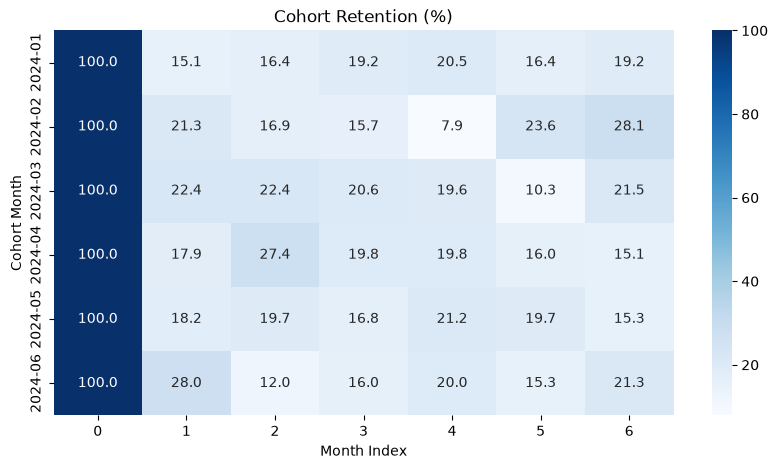

Month 1 리텐션 최고 코호트: 2024-06
Month 1 리텐션: 28.0%
Month 1 리텐션 최저 코호트: 2024-01
Month 1 리텐션: 15.1%


In [4]:
# 필수 1 코드를 작성하세요.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 1. 기능 사용 월
valid_usage['activity_month'] = (
    valid_usage['usage_date'].dt.to_period('M')
)


# 2. 구독별 첫 활동 월 = 코호트 월
valid_usage['cohort_month'] = (
    valid_usage.groupby('subscription_id')['activity_month']
    .transform('min')
)


# 3. 첫 활동 후 몇 개월째인지 계산
valid_usage['month_index'] = (
    (valid_usage['activity_month'].dt.year
     - valid_usage['cohort_month'].dt.year) * 12
    +
    (valid_usage['activity_month'].dt.month
     - valid_usage['cohort_month'].dt.month)
)


# 4. 코호트별 최초 구독 수
cohort_sizes = (
    valid_usage.groupby('cohort_month')['subscription_id']
    .nunique()
)


# 5. 코호트별 / 월별 고유 구독 수
cohort_counts = (
    valid_usage.groupby(['cohort_month', 'month_index'])
    ['subscription_id']
    .nunique()
    .unstack()
)


# 6. 리텐션 테이블
retention_table = cohort_counts.div(cohort_sizes, axis=0)


# 7. 2024년 1~6월, Month 0~6
selected_retention = retention_table.reindex(
    index=pd.period_range('2024-01', '2024-06', freq='M'),
    columns=range(7)
)

display((selected_retention * 100).round(1))


plt.figure(figsize=(10, 5))

sns.heatmap(
    selected_retention * 100,
    annot=True,
    fmt='.1f',
    cmap='Blues'
)

plt.xlabel('Month Index')
plt.ylabel('Cohort Month')
plt.title('Cohort Retention (%)')

plt.show()


month1 = selected_retention[1]

print("Month 1 리텐션 최고 코호트:", month1.idxmax())
print("Month 1 리텐션:", f"{month1.max():.1%}")

print("Month 1 리텐션 최저 코호트:", month1.idxmin())
print("Month 1 리텐션:", f"{month1.min():.1%}")

### 필수 1 답변 작성란

- **Q1.**
- **Q2.**
- **Q3.**
- **Q4.**

---

## 필수 2. 요금제별 Month 1 리텐션 비교하기

### 문제 2-1. 어떤 요금제의 초기 유지율이 상대적으로 낮은가?

#### 문제 설명

2024년 1월부터 6월까지 첫 기능 사용을 시작한 구독을 대상으로 요금제별 Month 1 리텐션을 비교하세요.

이 문제는 **코호트 기준과 속성 기반 세그먼트인 `plan_tier`를 교차하여 분석**하는 문제입니다.

#### 요구사항

1. 구독별 `cohort_month`, `plan_tier`를 한 행으로 정리한 `cohort_base`를 만드세요.
2. 2024년 1월~6월 코호트만 `selected_base`에 저장하세요.
3. 요금제별 코호트 구독 수를 계산하세요.
4. `month_index == 1`인 기록을 이용해 요금제별 Month 1 재사용 구독 수를 계산하세요.
5. 두 값을 나누어 `plan_retention`을 만드세요.
6. Month 1 리텐션이 낮은 순서로 정렬하고 백분율로 출력하세요.
7. 요금제별 Month 1 리텐션을 막대그래프로 시각화하세요.
8. 가장 낮은 요금제를 찾아 개선 방향과 추가 확인 데이터를 제안하세요.

#### 해석 질문

**Q1.** 이 분석에서 `plan_tier`는 어떤 세그멘테이션 기준인가요?  

고객의 계약 요금제라는 특성을 기주능로 나누었다(속성 기반 세그맨테이션)

**Q2.** Month 1 리텐션이 가장 낮은 요금제는 무엇인가요?  
Basic 이며 약 18.8% 정도

**Q3.** 전체 리텐션만 보는 것보다 요금제별로 나누어 보는 것이 유용한 이유는 무엇인가요?  

전체 평균에 가려진 낮은 요금제 그룹을 찾아 개선 대상을 더 구체적으로 정할 수 있다


**Q4.** 요금제별 차이만으로 낮은 리텐션의 원인을 확정할 수 있나요?

없다. 요금제와 고객 규모,` 기능 사용 유형, 지역별 차이 등 다른 요인이 있을 수 있으므로 추가 분석 필요


#### 제출 결과

- `cohort_base`와 `selected_base`
- `plan_retention` 결과
- 요금제별 리텐션 그래프
- 개선 방향과 추가 확인 데이터
- Q1~Q4 답변

,cohort_size,month1_users,retention_rate
plan_tier,,,
Basic,223,42,18.83
Pro,219,48,21.92
Enterprise,220,50,22.73


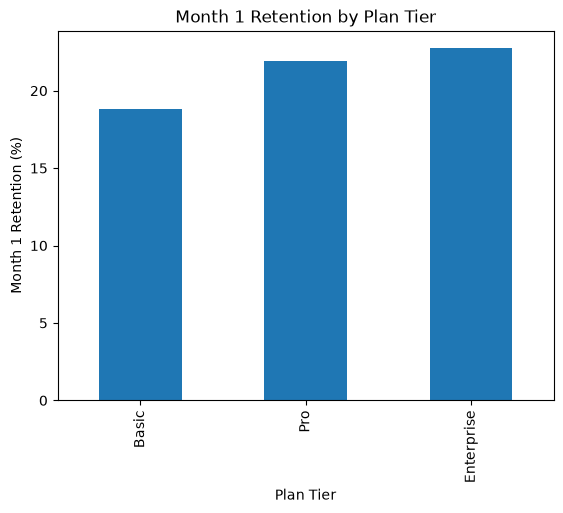

In [7]:
# 필수 2 코드를 작성하세요.

# 1. 구독별 cohort_month, plan_tier
cohort_base = (
    valid_usage[
        ['subscription_id', 'cohort_month', 'plan_tier']
    ]
    .drop_duplicates('subscription_id')
)


# 2. 2024년 1~6월 코호트
selected_base = cohort_base[
    cohort_base['cohort_month'].between('2024-01', '2024-06')
].copy()


# 3. 요금제별 코호트 구독 수
cohort_size = (
    selected_base.groupby('plan_tier')['subscription_id']
    .nunique()
)


# 4. 요금제별 Month 1 재사용 구독 수
month1_users = (
    valid_usage[
        (valid_usage['month_index'] == 1) &
        (valid_usage['subscription_id'].isin(selected_base['subscription_id']))
    ]
    .groupby('plan_tier')['subscription_id']
    .nunique()
)


# 5. Month 1 리텐션
plan_retention = pd.DataFrame({
    'cohort_size': cohort_size,
    'month1_users': month1_users
}).fillna(0)

plan_retention['retention_rate'] = (
    plan_retention['month1_users']
    / plan_retention['cohort_size']
)


# 6. 낮은 순으로 정렬 + 백분율 출력
plan_retention = plan_retention.sort_values('retention_rate')

plan_retention['retention_rate'] = (
    plan_retention['retention_rate'] * 100
).round(2)

display(plan_retention)


import matplotlib.pyplot as plt

plan_retention['retention_rate'].plot(kind='bar')

plt.ylabel('Month 1 Retention (%)')
plt.xlabel('Plan Tier')
plt.title('Month 1 Retention by Plan Tier')

plt.show()



### 필수 2 답변 작성란

- **Q1.**
- **Q2.**
- **Q3.**
- **Q4.**

---

## 과제 1. 평가 문항 기반 독립 과제

### 문제 3-1. 코호트·결제 주기별 Month 1~3 리텐션 비교하기

#### 문제 설명

2024년 1월부터 6월까지의 첫 유효 기능 사용 월 코호트를 대상으로, 월간 결제 구독과 연간 결제 구독의 Month 1~3 리텐션을 비교하세요. 시간이 지나면서 유지율이 어떻게 변하는지 확인하고 개선 방향을 제안하세요.

> 필수 1의 월별 코호트 분석과 필수 2의 세그먼트별 비교 절차를 활용하는 문제입니다.

#### 요구사항

1. 구독별 cohort_month, billing_frequency를 한 행으로 정리하세요.
2. 2024년 1월~6월 코호트만 선택하고, 각 코호트의 Month 3까지 관찰 가능한지 확인하세요. 아직 관찰하지 못한 월은 리텐션을 0으로 처리하지 마세요.
3. 코호트·결제 주기별 최초 구독 수와 Month 1·2·3 각각의 고유 재사용 구독 수를 계산하세요. 같은 구독이 같은 달에 여러 번 사용해도 한 번만 세세요.
4. 다음 식으로 billing_retention을 만드세요.
- 리텐션 = 해당 경과 월의 고유 재사용 구독 수 ÷ 해당 코호트·결제 주기의 최초 구독 수
- Month 1~3 모두 같은 최초 구독 수를 분모로 사용하세요.
- 이전 달에 사용하지 않았어도 해당 달에 다시 사용했다면 포함하세요.
5. 행은 코호트·결제 주기, 열은 Month 1~3인 리텐션 표를 만들고 백분율로 출력하세요.
6. 코호트별로 월간·연간 결제 구독의 Month 1~3 리텐션을 비교하는 선그래프를 그리세요.
7. 각 코호트에서 두 결제 주기의 Month 1 리텐션 차이와, 각 결제 주기의 Month 1→2 및 Month 2→3 변화폭을 %p로 계산하세요. 감소·유지·회복 등의 패턴을 실제 결과에 맞게 해석하세요.
8. 우선 점검할 코호트·결제 주기 조합을 선택하고, 수치 근거·가능한 원인 가설·개선 방향·추가 확인 데이터를 제안하세요. 원인 가설을 확인된 사실처럼 단정하지 마세요.

#### 해석 질문

**Q1.** 각 코호트에서 Month 1 리텐션이 더 낮은 결제 주기는 무엇이며, 두 결제 주기의 차이는 몇 %p인가요?

**Q2.** 코호트·결제 주기별 Month 1→2 및 Month 2→3 변화폭은 몇 %p이며, 어떤 유지 패턴이 나타나나요?

**Q3.** 우선 점검할 코호트·결제 주기는 무엇인가요? 수치 근거와 가능한 원인 가설, 개선 방향을 설명하세요.

**Q4.** 이 결과만으로 결제 주기가 낮은 리텐션의 원인이라고 판단할 수 있나요? 추가로 어떤 데이터를 확인해야 하나요?

#### 제출 결과

- 코호트·결제 주기별 최초 구독 수와 Month 1~3 고유 재사용 구독 수
- billing_retention 표와 리텐션 선그래프
- 결제 주기 간 차이와 경과 월별 변화폭(%p)
- 시간 경과에 따른 유지 패턴 해석
- 우선 점검 대상·원인 가설·개선 방향·추가 확인 데이터
- Q1~Q4 답변

데이터 마지막 관찰 월: 2024-12

=== 코호트별 구독 정보 ===


,subscription_id,cohort_month,billing_frequency
15,S-00b0bc,2024-02,annual
41,S-021004,2024-02,monthly
42,S-021297,2024-03,annual
71,S-0334aa,2024-03,annual
82,S-03a939,2024-04,monthly



=== 코호트별 관찰 가능 여부 ===


,cohort_month,available_months,M1_observable,M2_observable,M3_observable
0,2024-01,11,True,True,True
1,2024-02,10,True,True,True
2,2024-03,9,True,True,True
3,2024-04,8,True,True,True
4,2024-05,7,True,True,True
5,2024-06,6,True,True,True



=== 최초 구독 수 ===


...

,cohort_month,billing_frequency,month,initial_count,reused_count,retention
0,2024-01,annual,1,37,8,0.216216
1,2024-01,annual,2,37,4,0.108108
2,2024-01,annual,3,37,6,0.162162
3,2024-01,monthly,1,52,8,0.153846
4,2024-01,monthly,2,52,11,0.211538
5,2024-01,monthly,3,52,13,0.250000
6,2024-02,annual,1,26,4,0.153846
7,2024-02,annual,2,26,4,0.153846
8,2024-02,annual,3,26,6,0.230769
9,2024-02,monthly,1,41,16,0.390244



=== 코호트·결제 주기별 최초 구독 수 + 재사용 구독 수 ===


,cohort_month,billing_frequency,initial_count,Month_1_count,Month_2_count,Month_3_count
0,2024-01,annual,37,8,4,6
1,2024-01,monthly,52,8,11,13
2,2024-02,annual,26,4,4,6
3,2024-02,monthly,41,16,6,5
4,2024-03,annual,19,3,4,4
5,2024-03,monthly,16,2,2,5
6,2024-04,annual,22,6,4,6
7,2024-04,monthly,24,4,5,4
8,2024-05,annual,17,0,1,2
9,2024-05,monthly,13,1,2,1



=== billing_retention 표 ===


month,cohort_month,billing_frequency,Month_1,Month_2,Month_3
0,2024-01,annual,21.62%,10.81%,16.22%
1,2024-01,monthly,15.38%,21.15%,25.00%
2,2024-02,annual,15.38%,15.38%,23.08%
3,2024-02,monthly,39.02%,14.63%,12.20%
4,2024-03,annual,15.79%,21.05%,21.05%
5,2024-03,monthly,12.50%,12.50%,31.25%
6,2024-04,annual,27.27%,18.18%,27.27%
7,2024-04,monthly,16.67%,20.83%,16.67%
8,2024-05,annual,0.00%,5.88%,11.76%
9,2024-05,monthly,7.69%,15.38%,7.69%


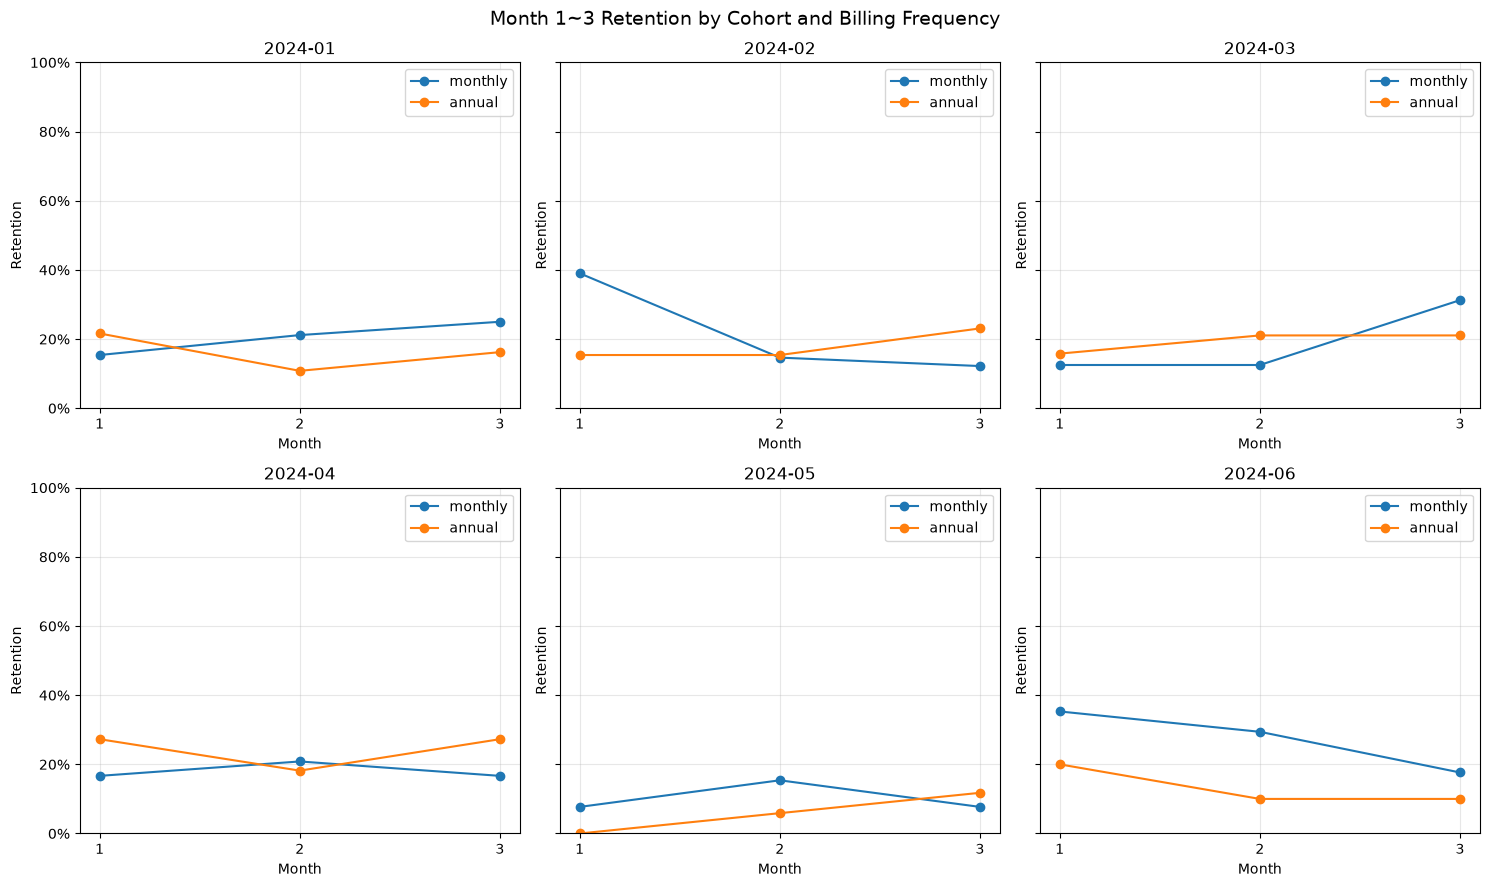


=== Q1. 코호트별 Month 1 비교 ===


billing_frequency,cohort_month,annual,monthly,lower_billing,M1_gap_pp
0,2024-01,21.62%,15.38%,monthly,6.24
1,2024-02,15.38%,39.02%,annual,23.64
2,2024-03,15.79%,12.50%,monthly,3.29
3,2024-04,27.27%,16.67%,monthly,10.61
4,2024-05,0.00%,7.69%,annual,7.69
5,2024-06,20.00%,35.29%,annual,15.29



=== Q2. 리텐션 변화폭 및 패턴 ===


month,cohort_month,billing_frequency,Month_1,Month_2,Month_3,M1_to_M2_pp,M2_to_M3_pp,pattern
0,2024-01,annual,21.62%,10.81%,16.22%,-10.81,5.41,감소 후 회복
1,2024-01,monthly,15.38%,21.15%,25.00%,5.77,3.85,지속 상승
2,2024-02,annual,15.38%,15.38%,23.08%,0.00,7.69,유지 후 상승
3,2024-02,monthly,39.02%,14.63%,12.20%,-24.39,-2.44,지속 감소
4,2024-03,annual,15.79%,21.05%,21.05%,5.26,0.00,상승 후 유지
5,2024-03,monthly,12.50%,12.50%,31.25%,0.00,18.75,유지 후 상승
6,2024-04,annual,27.27%,18.18%,27.27%,-9.09,9.09,감소 후 회복
7,2024-04,monthly,16.67%,20.83%,16.67%,4.17,-4.17,상승 후 감소
8,2024-05,annual,0.00%,5.88%,11.76%,5.88,5.88,지속 상승
9,2024-05,monthly,7.69%,15.38%,7.69%,7.69,-7.69,상승 후 감소



=== Q3. 우선 점검 대상 ===
코호트: 2024-05
결제 주기: annual
Month 1: 0.00%
Month 2: 5.88%
Month 3: 11.76%
Month 1~3 평균 리텐션: 5.88%

=== 가능한 원인 가설 ===
해당 코호트·결제 주기에서 초기 기능 사용 이후 반복 사용으로 이어지는 경험이 상대적으로 약했을 가능성이 있다.
다만 현재 결과만으로 결제 주기 자체가 원인이라고 확정할 수는 없다.

=== 개선 방향 ===
Month 1 이전의 초기 사용 경험과 핵심 기능 이용률을 점검하고, 초기 사용자에게 핵심 기능 안내·재사용 유도 메시지·온보딩을 강화하는 방안을 검토할 수 있다.

=== 추가 확인 데이터 ===
- plan_tier별 구성 차이
- feature_name별 사용 여부와 사용 빈도
- usage_count / usage_duration_secs
- error_count
- seats 등 고객 규모
- upgrade / downgrade / churn 여부
- 가능하다면 가입 경로, 고객 유형, 해지 사유

Q1. 각 코호트의 Month 1 비교
2024-01: monthly가 더 낮으며, 차이는 6.24%p
2024-02: annual가 더 낮으며, 차이는 23.64%p
2024-03: monthly가 더 낮으며, 차이는 3.29%p
2024-04: monthly가 더 낮으며, 차이는 10.61%p
2024-05: annual가 더 낮으며, 차이는 7.69%p
2024-06: annual가 더 낮으며, 차이는 15.29%p

Q2. Month 1→2 / Month 2→3 변화
2024-01 / annual: M1→M2 -10.81%p, M2→M3 5.41%p, 패턴 = 감소 후 회복
2024-01 / monthly: M1→M2 5.77%p, M2→M3 3.85%p, 패턴 = 지속 상승
2024-02 / annual: M1→M2 0.00%p, M2→M3 7.69%p, 패턴 = 유지 후 상승
2024-02 / mo

In [9]:
# 과제 1 코드를 작성하세요.


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter


# ============================================================
# 0. 데이터 준비
# ============================================================

# 날짜형 변환
subscriptions['start_date'] = pd.to_datetime(
    subscriptions['start_date'], errors='coerce'
)

subscriptions['end_date'] = pd.to_datetime(
    subscriptions['end_date'], errors='coerce'
)

feature_usage['usage_date'] = pd.to_datetime(
    feature_usage['usage_date'], errors='coerce'
)

# usage_id 중복 제거
feature_usage_clean = (
    feature_usage
    .drop_duplicates(subset='usage_id')
    .copy()
)

# 유효 기능 사용:
# usage_count > 0인 경우 실제 기능 사용으로 정의
valid_usage = feature_usage_clean[
    feature_usage_clean['usage_count'] > 0
].copy()

valid_usage['usage_month'] = (
    valid_usage['usage_date']
    .dt.to_period('M')
)

# 데이터에서 관찰 가능한 마지막 월
data_end_month = valid_usage['usage_month'].max()

print("데이터 마지막 관찰 월:", data_end_month)


# ============================================================
# 1. 구독별 cohort_month + billing_frequency 한 행으로 정리
#    cohort_month = 첫 유효 기능 사용 월
# ============================================================

first_usage = (
    valid_usage
    .groupby('subscription_id', as_index=False)
    ['usage_month']
    .min()
    .rename(columns={'usage_month': 'cohort_month'})
)

subscription_info = (
    subscriptions[
        ['subscription_id', 'billing_frequency']
    ]
    .drop_duplicates(subset='subscription_id')
)

cohort_info = first_usage.merge(
    subscription_info,
    on='subscription_id',
    how='left'
)

# 2024년 1월 ~ 6월 코호트만 선택
cohort_start = pd.Period('2024-01', freq='M')
cohort_end = pd.Period('2024-06', freq='M')

cohort_info = cohort_info[
    cohort_info['cohort_month'].between(
        cohort_start,
        cohort_end
    )
].copy()

print("\n=== 코호트별 구독 정보 ===")
display(cohort_info.head())


# ============================================================
# 2. Month 3까지 관찰 가능한지 확인
# ============================================================

def month_difference(later, earlier):
    return (
        (later.year - earlier.year) * 12
        + later.month
        - earlier.month
    )


cohort_info['available_months'] = (
    cohort_info['cohort_month']
    .apply(
        lambda x: month_difference(
            data_end_month,
            x
        )
    )
)

cohort_info['M1_observable'] = (
    cohort_info['available_months'] >= 1
)

cohort_info['M2_observable'] = (
    cohort_info['available_months'] >= 2
)

cohort_info['M3_observable'] = (
    cohort_info['available_months'] >= 3
)


observation_check = (
    cohort_info
    .groupby('cohort_month', as_index=False)
    .agg(
        available_months=('available_months', 'max'),
        M1_observable=('M1_observable', 'max'),
        M2_observable=('M2_observable', 'max'),
        M3_observable=('M3_observable', 'max')
    )
)

print("\n=== 코호트별 관찰 가능 여부 ===")
display(observation_check)


# ============================================================
# 3. 사용 이벤트에 cohort_month 연결
# ============================================================

usage_cohort = valid_usage[
    ['subscription_id', 'usage_month']
].drop_duplicates()

usage_cohort = usage_cohort.merge(
    cohort_info[
        [
            'subscription_id',
            'cohort_month',
            'billing_frequency'
        ]
    ],
    on='subscription_id',
    how='inner'
)


# 각 사용 월이 cohort 이후 몇 개월인지 계산
usage_cohort['month_offset'] = (
    (usage_cohort['usage_month'].dt.year
     - usage_cohort['cohort_month'].dt.year) * 12
    +
    (
        usage_cohort['usage_month'].dt.month
        - usage_cohort['cohort_month'].dt.month
    )
)


# ============================================================
# 4. 코호트·결제 주기별 최초 구독 수
# ============================================================

base_counts = (
    cohort_info
    .groupby(
        ['cohort_month', 'billing_frequency']
    )
    ['subscription_id']
    .nunique()
    .reset_index(name='initial_count')
)

print("\n=== 최초 구독 수 ===")
display(base_counts)


# ============================================================
# 5. Month 1~3 고유 재사용 구독 수 계산
# ============================================================

retention_rows = []

for _, row in base_counts.iterrows():

    cohort = row['cohort_month']
    billing = row['billing_frequency']
    initial_count = row['initial_count']

    # 해당 cohort의 관찰 가능 개월 수
    available_months = month_difference(
        data_end_month,
        cohort
    )

    for month_n in [1, 2, 3]:

        # 아직 관찰할 수 없는 월이면 0이 아니라 NaN
        if available_months < month_n:

            reused_count = np.nan
            retention = np.nan

        else:

            reused_count = (
                usage_cohort[
                    (usage_cohort['cohort_month'] == cohort)
                    &
                    (
                        usage_cohort['billing_frequency']
                        == billing
                    )
                    &
                    (
                        usage_cohort['month_offset']
                        == month_n
                    )
                ]
                ['subscription_id']
                .nunique()
            )

            retention = (
                reused_count / initial_count
                if initial_count > 0
                else np.nan
            )

        retention_rows.append({
            'cohort_month': cohort,
            'billing_frequency': billing,
            'month': month_n,
            'initial_count': initial_count,
            'reused_count': reused_count,
            'retention': retention
        })


billing_retention = pd.DataFrame(
    retention_rows
)

print("\n=== billing_retention ===")
display(billing_retention)


# ============================================================
# 6. 제출용 Count 표
# ============================================================

reuse_counts = (
    billing_retention
    .pivot(
        index=[
            'cohort_month',
            'billing_frequency'
        ],
        columns='month',
        values='reused_count'
    )
    .rename(
        columns={
            1: 'Month_1_count',
            2: 'Month_2_count',
            3: 'Month_3_count'
        }
    )
    .reset_index()
)

count_table = base_counts.merge(
    reuse_counts,
    on=[
        'cohort_month',
        'billing_frequency'
    ],
    how='left'
)

print("\n=== 코호트·결제 주기별 최초 구독 수 + 재사용 구독 수 ===")
display(count_table)


# ============================================================
# 7. Month 1~3 리텐션 표
# ============================================================

billing_retention_wide = (
    billing_retention
    .pivot(
        index=[
            'cohort_month',
            'billing_frequency'
        ],
        columns='month',
        values='retention'
    )
    .rename(
        columns={
            1: 'Month_1',
            2: 'Month_2',
            3: 'Month_3'
        }
    )
    .reset_index()
)

print("\n=== billing_retention 표 ===")

display(
    billing_retention_wide.style.format({
        'Month_1': '{:.2%}',
        'Month_2': '{:.2%}',
        'Month_3': '{:.2%}'
    })
)


# ============================================================
# 8. 코호트별 monthly / annual 리텐션 선그래프
# ============================================================

cohorts = sorted(
    billing_retention['cohort_month'].unique()
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9),
    sharey=True
)

axes = axes.flatten()

for ax, cohort in zip(axes, cohorts):

    temp = billing_retention[
        billing_retention['cohort_month']
        == cohort
    ]

    for billing in ['monthly', 'annual']:

        line = temp[
            temp['billing_frequency']
            == billing
        ].sort_values('month')

        if len(line) == 0:
            continue

        ax.plot(
            line['month'],
            line['retention'],
            marker='o',
            label=billing
        )

    ax.set_title(str(cohort))
    ax.set_xlabel('Month')
    ax.set_ylabel('Retention')
    ax.set_xticks([1, 2, 3])
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(
        PercentFormatter(1)
    )
    ax.grid(alpha=0.3)
    ax.legend()

# 코호트가 6개 미만인 경우 남는 그래프 숨김
for i in range(len(cohorts), len(axes)):
    axes[i].set_visible(False)

plt.suptitle(
    'Month 1~3 Retention by Cohort and Billing Frequency',
    fontsize=14
)

plt.tight_layout()
plt.show()


# ============================================================
# 9. Q1
#    코호트별 Month 1 monthly vs annual 비교
# ============================================================

m1 = billing_retention[
    billing_retention['month'] == 1
].pivot(
    index='cohort_month',
    columns='billing_frequency',
    values='retention'
).reset_index()


def lower_billing(row):

    monthly = row.get('monthly', np.nan)
    annual = row.get('annual', np.nan)

    if pd.isna(monthly) or pd.isna(annual):
        return '비교 불가'

    if monthly < annual:
        return 'monthly'

    elif annual < monthly:
        return 'annual'

    else:
        return '동일'


m1['lower_billing'] = m1.apply(
    lower_billing,
    axis=1
)

if (
    'monthly' in m1.columns
    and 'annual' in m1.columns
):

    m1['M1_gap_pp'] = (
        (
            m1['monthly']
            - m1['annual']
        ).abs()
        * 100
    )

else:

    m1['M1_gap_pp'] = np.nan


print("\n=== Q1. 코호트별 Month 1 비교 ===")

display(
    m1.style.format({
        'monthly': '{:.2%}',
        'annual': '{:.2%}',
        'M1_gap_pp': '{:.2f}'
    })
)


# ============================================================
# 10. Q2
#     Month 1 → 2 / Month 2 → 3 변화폭
# ============================================================

change_table = (
    billing_retention_wide.copy()
)

change_table['M1_to_M2_pp'] = (
    (
        change_table['Month_2']
        - change_table['Month_1']
    )
    * 100
)

change_table['M2_to_M3_pp'] = (
    (
        change_table['Month_3']
        - change_table['Month_2']
    )
    * 100
)


# 패턴 판정
# ±0.5%p 이내는 '유지'로 간주
def classify_pattern(row):

    d12 = row['M1_to_M2_pp']
    d23 = row['M2_to_M3_pp']

    if pd.isna(d12) or pd.isna(d23):
        return '관찰 미완료'

    tolerance = 0.5

    if d12 < -tolerance and d23 < -tolerance:
        return '지속 감소'

    elif d12 < -tolerance and d23 > tolerance:
        return '감소 후 회복'

    elif d12 > tolerance and d23 > tolerance:
        return '지속 상승'

    elif d12 > tolerance and d23 < -tolerance:
        return '상승 후 감소'

    elif (
        abs(d12) <= tolerance
        and abs(d23) <= tolerance
    ):
        return '대체로 유지'

    elif abs(d12) <= tolerance:
        if d23 > tolerance:
            return '유지 후 상승'
        else:
            return '유지 후 감소'

    elif abs(d23) <= tolerance:
        if d12 > tolerance:
            return '상승 후 유지'
        else:
            return '감소 후 유지'

    return '혼합 패턴'


change_table['pattern'] = change_table.apply(
    classify_pattern,
    axis=1
)

print("\n=== Q2. 리텐션 변화폭 및 패턴 ===")

display(
    change_table.style.format({
        'Month_1': '{:.2%}',
        'Month_2': '{:.2%}',
        'Month_3': '{:.2%}',
        'M1_to_M2_pp': '{:.2f}',
        'M2_to_M3_pp': '{:.2f}'
    })
)


# ============================================================
# 11. Q3
#     우선 점검 대상 선택
#
# Month 1~3가 모두 관찰 가능한 조합 중
# 세 달 평균 리텐션이 가장 낮은 조합을 우선 점검
# ============================================================

priority_candidates = (
    billing_retention_wide
    .dropna(
        subset=[
            'Month_1',
            'Month_2',
            'Month_3'
        ]
    )
    .copy()
)

if len(priority_candidates) > 0:

    priority_candidates[
        'mean_retention'
    ] = (
        priority_candidates[
            ['Month_1', 'Month_2', 'Month_3']
        ]
        .mean(axis=1)
    )

    priority = priority_candidates.loc[
        priority_candidates[
            'mean_retention'
        ].idxmin()
    ]

else:

    # Month 3까지 관찰 가능한 조합이 없다면
    # Month 1이 가장 낮은 조합 사용
    priority_candidates = (
        billing_retention_wide
        .dropna(subset=['Month_1'])
        .copy()
    )

    priority = priority_candidates.loc[
        priority_candidates[
            'Month_1'
        ].idxmin()
    ]


priority_cohort = priority['cohort_month']
priority_billing = priority['billing_frequency']

print("\n=== Q3. 우선 점검 대상 ===")

print(
    f"코호트: {priority_cohort}"
)

print(
    f"결제 주기: {priority_billing}"
)

print(
    f"Month 1: {priority['Month_1']:.2%}"
)

if not pd.isna(priority['Month_2']):
    print(
        f"Month 2: {priority['Month_2']:.2%}"
    )

if not pd.isna(priority['Month_3']):
    print(
        f"Month 3: {priority['Month_3']:.2%}"
    )

if 'mean_retention' in priority.index:

    print(
        f"Month 1~3 평균 리텐션: "
        f"{priority['mean_retention']:.2%}"
    )


# ============================================================
# 12. 개선 가설
# ============================================================

print("\n=== 가능한 원인 가설 ===")

print(
    "해당 코호트·결제 주기에서 초기 기능 사용 이후 "
    "반복 사용으로 이어지는 경험이 상대적으로 약했을 가능성이 있다."
)

print(
    "다만 현재 결과만으로 결제 주기 자체가 원인이라고 "
    "확정할 수는 없다."
)


print("\n=== 개선 방향 ===")

print(
    "Month 1 이전의 초기 사용 경험과 핵심 기능 이용률을 점검하고, "
    "초기 사용자에게 핵심 기능 안내·재사용 유도 메시지·"
    "온보딩을 강화하는 방안을 검토할 수 있다."
)


print("\n=== 추가 확인 데이터 ===")

print(
    "- plan_tier별 구성 차이"
)

print(
    "- feature_name별 사용 여부와 사용 빈도"
)

print(
    "- usage_count / usage_duration_secs"
)

print(
    "- error_count"
)

print(
    "- seats 등 고객 규모"
)

print(
    "- upgrade / downgrade / churn 여부"
)

print(
    "- 가능하다면 가입 경로, 고객 유형, 해지 사유"
)


# ============================================================
# 13. Q1 ~ Q4 자동 출력
# ============================================================

print("\n" + "=" * 70)
print("Q1. 각 코호트의 Month 1 비교")
print("=" * 70)

for _, row in m1.iterrows():

    cohort = row['cohort_month']

    if (
        pd.isna(row.get('monthly', np.nan))
        or pd.isna(row.get('annual', np.nan))
    ):

        print(
            f"{cohort}: 비교 가능한 데이터가 부족함"
        )

    else:

        print(
            f"{cohort}: "
            f"{row['lower_billing']}가 더 낮으며, "
            f"차이는 {row['M1_gap_pp']:.2f}%p"
        )


print("\n" + "=" * 70)
print("Q2. Month 1→2 / Month 2→3 변화")
print("=" * 70)

for _, row in change_table.iterrows():

    print(
        f"{row['cohort_month']} / "
        f"{row['billing_frequency']}: "
        f"M1→M2 {row['M1_to_M2_pp']:.2f}%p, "
        f"M2→M3 {row['M2_to_M3_pp']:.2f}%p, "
        f"패턴 = {row['pattern']}"
    )


print("\n" + "=" * 70)
print("Q3. 우선 점검 대상")
print("=" * 70)

print(
    f"{priority_cohort} 코호트의 "
    f"{priority_billing} 결제 구독을 "
    f"우선 점검 대상으로 볼 수 있다."
)

print(
    "Month 1~3 리텐션 수준이 상대적으로 낮아 "
    "반복 사용 과정의 점검 필요성이 크기 때문이다."
)

print(
    "가능한 원인으로는 초기 온보딩, "
    "핵심 기능 활용 정도, 사용자 구성 차이 등을 "
    "가설로 설정할 수 있다."
)

print(
    "초기 기능 안내와 재사용 유도 방식을 개선하고, "
    "기능별 사용량 및 사용자 특성을 추가로 확인할 필요가 있다."
)


print("\n" + "=" * 70)
print("Q4. 결제 주기가 원인인가?")
print("=" * 70)

print(
    "아니다. 현재 분석은 결제 주기와 리텐션 사이의 "
    "차이를 보여줄 뿐 인과관계를 증명하지 않는다."
)

print(
    "결제 주기별 plan_tier, 고객 규모, 기능 사용량, "
    "사용 시간, 오류 경험, 업그레이드·다운그레이드 여부, "
    "해지 여부 등의 구성 차이가 결과에 영향을 주었을 수 있다."
)

print(
    "따라서 이러한 변수들을 추가로 비교하거나 통제한 뒤 "
    "결제 주기와 리텐션의 관계를 다시 확인해야 한다."
)

### 과제 1 답변 작성란

**Q1.** 각 코호트에서 Month 1 리텐션이 더 낮은 결제 주기는 무엇이며, 두 결제 주기의 차이는 몇 %p인가요?

annual 23.64% 로 차이가 났다

**Q2.** 코호트·결제 주기별 Month 1→2 및 Month 2→3 변화폭은 몇 %p이며, 어떤 유지 패턴이 나타나나요?

변화율은 줄어든다고 단정 할 수 없으며 감소 했다가 회복하는 패턴도 있다.


**Q3.** 우선 점검할 코호트·결제 주기는 무엇인가요? 수치 근거와 가능한 원인 가설, 개선 방향을 설명하세요.

점검할 코호트는 2024-05 코호트를 점검한다.
moth 1 리텐션이 0.00%로 가장 낮고 month 5.88% month 3 11.76% 로 낮은 수준이 이어졌다.

개선방향은 온보딩 과정중 불편함이나 유도 방식의 스트레스가 문제로 작용 할 수 있으니 그것을 개선해보는것도 하나의 방법이라고 생각한다.

**Q4.** 이 결과만으로 결제 주기가 낮은 리텐션의 원인이라고 판단할 수 있나요? 추가로 어떤 데이터를 확인해야 하나요?

아니요 추가로 plan tier, 고객 규모, 기능 사용량, 사용 시간, 오류 경험 같은 다은 요인을 고려해야한다.


---

## 실습 마무리

아래 질문에 답하세요.

1. 이번 분석에서는 어떤 행동을 코호트의 출발점으로 사용했나요?

구독별 첫 유효 기능 사용 월을 출발점으로 사용했다.

2. 월간 N개월 리텐션은 어떻게 계산했나요?

첫 기능 사용월로 부터 N개월 뒤 기능을 다시 사용한 고유 구독 수를 해당 코호트의 최초 구독 수로 나누었다

3. 코호트와 세그먼트를 함께 분석하면 어떤 장점이 있나요?

같은 시기에 기능을 사용한 사용자 중에서도 어떤 특성의 그룹에서 유지(재방문율, 재구매율)이 낮은지 구체적으로 확인할 수 있다.

4. 어떤 세그먼트의 Month 1 리텐션이 상대적으로 낮았나요?

basic, 18.8% 정도로 낮았다.

5. 리텐션 차이와 실제 원인을 왜 구분해야 하나요?

리텐션 표는 어느 그룹이 낮은지는 보여주지만 요금제, 기능 경험, 고객 특성 중 무엇이 원인인지는 직접적으로 알려주지는 않음
